In [ ]:
!pip install -qU langchain langgraph langchain_community
!pip install -qU langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.2 MB/s eta 0:00:00


In [ ]:
from langchain_core.messages.ai import AIMessage
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage
import os
from google.colab import userdata
os.environ["GROQ_API_KEY"]=userdata.get("GROQ_API_KEY")


In [ ]:
llm=ChatGroq(model="qwen/qwen3.8-27b", temperature=0, max_tokens=200)
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.4', 'langchain': '1.4.2'}}, client=<groq.resources.chat.completions.Completions object at 0x7eafd6a774d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7eafd67582f0>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), max_tokens=200)

In [ ]:
from typing import TypedDict,List ,Annotated
from operator import add

class graph_schema(TypedDict):

  message_manual:List
  #Using Reducer in Langgraph
  message_auto:Annotated[List,add]

In [ ]:
def create_post(state:graph_schema)->graph_schema:

  message_manual = state['message_manual']
  response_manual = llm.invoke(message_manual).content
  response_manual_ai = AIMessage(content=response_manual)
  state['message_manual']=message_manual + [response_manual_ai]


  message_auto = state['message_auto']
  response_auto = llm.invoke(message_auto).content
  response_auto_ai = AIMessage(content=response_auto)
  state['message_auto']=[response_auto_ai]

  return state

def curate_post(state:graph_schema)->graph_schema:

  message_manual = state['message_manual']
  response_manual = llm.invoke(message_manual).content
  response_manual_ai = AIMessage(content=response_manual)
  state['message_manual']=message_manual + [response_manual_ai]


  message_auto = state['message_auto']
  response_auto = llm.invoke(message_auto).content
  response_auto_ai = AIMessage(content=response_auto)
  state['message_auto']=[response_auto_ai]

  return state

In [ ]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)

graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)

messages_graph = graph.compile()


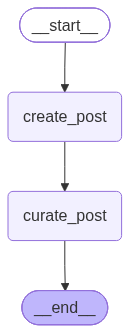

In [ ]:
from IPython.display import Image,display

Image(messages_graph.get_graph().draw_mermaid_png())

In [ ]:
messages_graph.invoke(
    {"message_manual": [HumanMessage(content="The importance of data privacy in the digital age")],
     "message_auto": [HumanMessage(content="The importance of data privacy in the digital age")]}
)

{'message_manual': [HumanMessage(content='The importance of data privacy in the digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content='In the digital age, data has become the "new oil"—a valuable resource that fuels innovation, drives business models, and shapes personal experiences. However, with this value comes significant responsibility. **Data privacy** is no longer just a technical concern or a legal checkbox; it is a fundamental human right and a critical pillar of trust in the digital ecosystem.\n\nHere’s why data privacy is so important today:\n\n### 1. Protection of Personal Autonomy and Identity\nPersonal data—including names, addresses, financial records, health information, and even biometric data—forms the core of our digital identity. When this data is compromised or misused, individuals lose control over their own narratives.\n- **Identity Theft**: Leaked data can be used to impersonate individuals, leading to financial loss and emotional distre